In [1]:
pip install pandas numpy matplotlib seaborn jupyter lightgbm xgboost scikit-learn shap catboost -q

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

train_transaction = pd.read_csv("../data/train_transaction.csv")
train_identity = pd.read_csv("../data/train_identity.csv")

train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(train_transaction.shape)
print(train_identity.shape)

(590540, 394)
(144233, 41)


In [4]:
train_transaction.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train_transaction["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [6]:
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [7]:
train_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [8]:
train_transaction.isnull().sum().sort_values(ascending=False).head(20)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V139     508595
V162     508595
V161     508595
V154     508595
V138     508595
V158     508595
V157     508595
V163     508595
V156     508595
V155     508595
V149     508595
dtype: int64

In [9]:
print(train_transaction.shape)
print(train_identity.shape)

(590540, 394)
(144233, 41)


In [10]:
train_transaction.columns[:20]


Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3'],
      dtype='object')

In [11]:
train_transaction["isFraud"].value_counts()
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [12]:
train_transaction["TransactionAmt"].describe()


count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [13]:
train_transaction[["TransactionAmt","isFraud"]].groupby("isFraud").describe()

TransactionAmt                                                      \
                 count        mean         std    min     25%   50%    75%   
isFraud                                                                      
0             569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1              20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

                    
               max  
isFraud             
0        31937.391  
1         5191.000

In [14]:
import matplotlib.pyplot as plt
import numpy as np

print(np.__version__)

1.26.4


<Axes: >

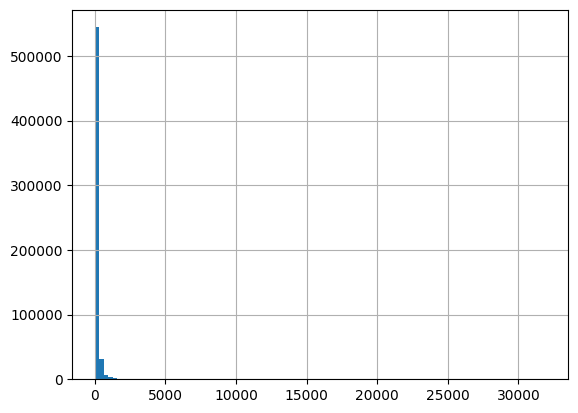

In [15]:
train_transaction["TransactionAmt"].hist(bins=100)

In [16]:
import matplotlib
print(matplotlib.__version__)

3.8.4


In [17]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)

3.8.4


<Axes: >

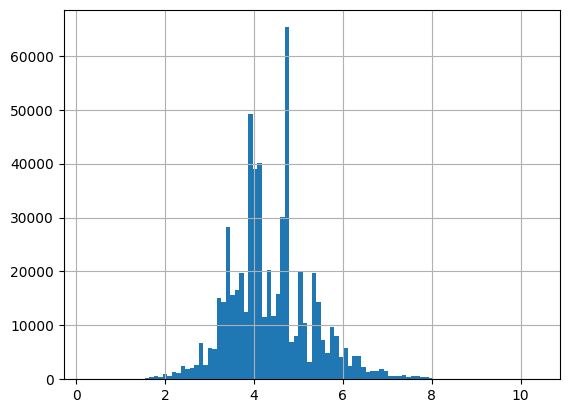

In [18]:
import numpy as np

np.log1p(train_transaction["TransactionAmt"]).hist(bins=100)

In [19]:
train_transaction.groupby("isFraud")["TransactionAmt"].median()


isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

In [20]:
train_transaction.groupby("isFraud")["TransactionAmt"].mean()


isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

In [21]:
train_transaction["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

In [22]:
pd.crosstab(
    train_transaction["ProductCD"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


In [23]:
train_transaction["card4"].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

In [24]:
pd.crosstab(
    train_transaction["card4"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
card4,,
american express,97.130163,2.869837
discover,92.271839,7.728161
mastercard,96.566905,3.433095
visa,96.524390,3.475610


In [25]:
pd.crosstab(
    train_transaction["P_emaildomain"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
P_emaildomain,,
aim.com,87.301587,12.698413
anonymous.com,97.678253,2.321747
aol.com,97.818940,2.181060
att.net,99.256137,0.743863
bellsouth.net,97.223677,2.776323
cableone.net,98.113208,1.886792
centurylink.net,100.000000,0.000000
cfl.rr.com,100.000000,0.000000
charter.net,96.936275,3.063725


In [26]:
train_transaction["P_emaildomain"].value_counts().head(20)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
yahoo.com.mx       1543
me.com             1522
cox.net            1393
optonline.net      1011
charter.net         816
Name: count, dtype: int64

In [27]:
train_transaction["P_emaildomain"].value_counts().loc[
    ["protonmail.com","mail.com","outlook.com"]
]

P_emaildomain
protonmail.com      76
mail.com           559
outlook.com       5096
Name: count, dtype: int64

In [28]:
pd.crosstab(
    train_transaction["card6"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
card6,,
charge card,100.000000,0.000000
credit,93.321520,6.678480
debit,97.573749,2.426251
debit or credit,100.000000,0.000000


In [29]:
pd.crosstab(
    pd.cut(train_transaction["dist1"], bins=10),
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
dist1,,
"(-10.286, 1028.6]",98.023631,1.976369
"(1028.6, 2057.2]",97.454948,2.545052
"(2057.2, 3085.8]",97.584541,2.415459
"(3085.8, 4114.4]",96.850394,3.149606
"(4114.4, 5143.0]",98.347107,1.652893
"(5143.0, 6171.6]",100.000000,0.000000
"(6171.6, 7200.2]",100.000000,0.000000
"(7200.2, 8228.8]",100.000000,0.000000
"(9257.4, 10286.0]",100.000000,0.000000


In [30]:
train_transaction.groupby("isFraud")["TransactionDT"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,7.360791e+06,4.623930e+06,86400.0,3010651.0,7271678.0,11253338.0,15811131.0
1,20663.0,7.690033e+06,4.416551e+06,89760.0,3965858.0,7575230.0,11217428.0,15810876.0


In [31]:
pd.crosstab(
    train_transaction["P_emaildomain"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
P_emaildomain,,
aim.com,87.301587,12.698413
anonymous.com,97.678253,2.321747
aol.com,97.818940,2.181060
att.net,99.256137,0.743863
bellsouth.net,97.223677,2.776323
cableone.net,98.113208,1.886792
centurylink.net,100.000000,0.000000
cfl.rr.com,100.000000,0.000000
charter.net,96.936275,3.063725


In [32]:
merged = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

In [33]:
pd.crosstab(
    merged["DeviceType"],
    merged["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
DeviceType,,
desktop,93.478542,6.521458
mobile,89.833768,10.166232


In [34]:
merged.shape

(590540, 434)

In [35]:
pd.crosstab(
    merged["DeviceInfo"],
    merged["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
DeviceInfo,,
0PAJ5,100.0,0.0
0PJA2,100.0,0.0
0PM92,50.0,50.0
1016S,100.0,0.0
2PQ93,100.0,0.0
...,...,...
verykools5004,100.0,0.0
verykools5034,100.0,0.0
verykools5035,100.0,0.0


In [36]:
merged["DeviceInfo"].value_counts().head(20)

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
SM-G950F Build/NRD90M            225
Name: count, dtype: int64

In [37]:
pd.crosstab(
    merged["id_30"],
    merged["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
id_30,,
Android,89.434662,10.565338
Android 4.4.2,74.603175,25.396825
Android 5.0,100.000000,0.000000
Android 5.0.2,100.000000,0.000000
Android 5.1.1,71.142857,28.857143
...,...,...
iOS 11.3.1,97.794118,2.205882
iOS 11.4.0,80.000000,20.000000
iOS 11.4.1,100.000000,0.000000


In [38]:
device_stats = pd.crosstab(
    merged["id_30"],
    merged["isFraud"]
)

device_stats["FraudRate"] = (
    device_stats[1] /
    (device_stats[0] + device_stats[1])
) * 100

device_stats["TotalCount"] = (
    device_stats[0] + device_stats[1]
)

device_stats.sort_values(
    by="FraudRate",
    ascending=False
)

isFraud,0,1,FraudRate,TotalCount
id_30,,,,
other,6,9,60.000000,15
Android 5.1.1,249,101,28.857143,350
Android 4.4.2,47,16,25.396825,63
iOS 11.4.0,4,1,20.000000,5
iOS 11.0.1,102,25,19.685039,127
...,...,...,...,...
Mac OS X 10_13_5,4,0,0.000000,4
Mac OS X 10_7_5,93,0,0.000000,93
Mac OS X 10_8_5,74,0,0.000000,74


In [39]:
device_info_stats = pd.crosstab(
    merged["DeviceInfo"],
    merged["isFraud"]
)

device_info_stats["FraudRate"] = (
    device_info_stats[1] /
    (device_info_stats[0] + device_info_stats[1])
) * 100

device_info_stats["TotalCount"] = (
    device_info_stats[0] + device_info_stats[1]
)

device_info_stats[
    device_info_stats["TotalCount"] >= 100
].sort_values(
    by="FraudRate",
    ascending=False
).head(20)

isFraud,0,1,FraudRate,TotalCount
DeviceInfo,,,,
hi6210sft Build/MRA58K,10,180,94.736842,190
SM-A300H Build/LRX22G,34,169,83.251232,203
SM-J320M Build/LMY47V,114,57,33.333333,171
WAS-LX3 Build/HUAWEIWAS-LX3,80,28,25.925926,108
Moto Z2 Play Build/NPSS26.118-19-14,99,30,23.255814,129
Moto E (4) Plus Build/NMA26.42-69,128,32,20.000000,160
SM-J701M Build/NRD90M,124,30,19.480519,154
SM-G955F Build/NRD90M,108,26,19.402985,134
Moto E (4) Build/NMA26.42-69,102,23,18.400000,125


In [40]:
device_info_stats = pd.crosstab(
    merged["id_31"],
    merged["isFraud"]
)

device_info_stats["FraudRate"] = (
    device_info_stats[1] /
    (device_info_stats[0] + device_info_stats[1])
) * 100

device_info_stats["TotalCount"] = (
    device_info_stats[0] + device_info_stats[1]
)

device_info_stats[
    device_info_stats["TotalCount"] >= 100
].sort_values(
    by="FraudRate",
    ascending=False
).head(20)

isFraud,0,1,FraudRate,TotalCount
id_31,,,,
chrome 52.0 for android,94,58,38.157895,152
opera 49.0,95,43,31.159420,138
chrome 58.0,137,51,27.127660,188
chrome 50.0 for android,107,38,26.206897,145
android webview 4.0,216,69,24.210526,285
firefox,526,147,21.842496,673
other,251,61,19.551282,312
chrome 58.0 for android,212,50,19.083969,262
chrome 56.0 for android,194,44,18.487395,238


In [41]:
for col in ["addr1", "addr2"]:
    stats = pd.crosstab(
        train_transaction[col],
        train_transaction["isFraud"]
    )

    stats["FraudRate"] = stats[1] / (stats[0] + stats[1]) * 100
    stats["TotalCount"] = stats[0] + stats[1]

    display(
        stats[stats["TotalCount"] >= 100]
        .sort_values("FraudRate", ascending=False)
        .head(20)
    )

isFraud,0,1,FraudRate,TotalCount
addr1,,,,
296.0,289,78,21.253406,367
161.0,339,82,19.477435,421
536.0,259,50,16.181230,309
130.0,313,29,8.479532,342
465.0,461,42,8.349901,503
122.0,1500,117,7.235622,1617
308.0,1196,83,6.489445,1279
511.0,147,10,6.369427,157
324.0,2061,112,5.154165,2173


isFraud,0,1,FraudRate,TotalCount
addr2,,,,
96.0,549,89,13.949843,638
60.0,2805,279,9.046693,3084
87.0,508004,12477,2.397206,520481


In [42]:
for col in ["M4", "M6"]:
    stats = pd.crosstab(

        train_transaction[col],

        train_transaction["isFraud"]

    )

    stats["FraudRate"] = stats[1] / (stats[0] + stats[1]) * 100

    stats["TotalCount"] = stats[0] + stats[1]

    display(

        stats[stats["TotalCount"] >= 100]

        .sort_values("FraudRate", ascending=False)

        .head(20)

    )

isFraud,0,1,FraudRate,TotalCount
M4,,,,
M2,53056,6809,11.373925,59865
M0,189207,7198,3.664876,196405
M1,51397,1429,2.705107,52826


isFraud,0,1,FraudRate,TotalCount
M6,,,,
F,222459,5397,2.368601,227856
T,190029,3295,1.704393,193324


In [43]:
for col in ["M1","M2","M3","M5","M7","M8","M9"]:

    stats = pd.crosstab(

        train_transaction[col],

        train_transaction["isFraud"]

    )

    stats["FraudRate"] = stats[1] / (stats[0] + stats[1]) * 100

    stats["TotalCount"] = stats[0] + stats[1]

    display(

        stats[stats["TotalCount"] >= 100]

        .sort_values("FraudRate", ascending=False)

        .head(20)

    )

isFraud,0,1,FraudRate,TotalCount
M1,,,,
T,313073,6342,1.985505,319415


isFraud,0,1,FraudRate,TotalCount
M2,,,,
F,32788,1184,3.485223,33972
T,280310,5158,1.806858,285468


isFraud,0,1,FraudRate,TotalCount
M3,,,,
F,65660,2049,3.026186,67709
T,247438,4293,1.705392,251731


isFraud,0,1,FraudRate,TotalCount
M5,,,,
T,103512,4055,3.769744,107567
F,128977,3514,2.652256,132491


isFraud,0,1,FraudRate,TotalCount
M7,,,,
T,32173,728,2.212699,32901
F,207285,4089,1.934486,211374


isFraud,0,1,FraudRate,TotalCount
M8,,,,
F,151878,3373,2.172611,155251
T,87593,1444,1.621798,89037


isFraud,0,1,FraudRate,TotalCount
M9,,,,
F,37473,1159,3.000104,38632
T,201998,3658,1.778698,205656


In [44]:
train_transaction.groupby("isFraud")[
    ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"]
].mean()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
isFraud,,,,,,,,,,
0,13.314952,14.173283,0.005840,3.693878,5.722537,8.786377,2.517484,4.560881,4.580904,4.723526
1,35.535740,45.509413,0.000242,15.077336,1.406717,16.923148,11.977157,21.242608,1.703964,19.493926


In [45]:
for col in ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"]:
    print("\n", col)
    print(train_transaction.groupby("isFraud")[col].median())


 C1
isFraud
0    1.0
1    2.0
Name: C1, dtype: float64

 C2
isFraud
0    1.0
1    2.0
Name: C2, dtype: float64

 C3
isFraud
0    0.0
1    0.0
Name: C3, dtype: float64

 C4
isFraud
0    0.0
1    1.0
Name: C4, dtype: float64

 C5
isFraud
0    0.0
1    0.0
Name: C5, dtype: float64

 C6
isFraud
0    1.0
1    1.0
Name: C6, dtype: float64

 C7
isFraud
0    0.0
1    0.0
Name: C7, dtype: float64

 C8
isFraud
0    0.0
1    1.0
Name: C8, dtype: float64

 C9
isFraud
0    1.0
1    0.0
Name: C9, dtype: float64

 C10
isFraud
0    0.0
1    1.0
Name: C10, dtype: float64


In [46]:
train_transaction[[
    "TransactionAmt",
    "C1","C2","C4","C8","C10",
    "isFraud"
]].corr(numeric_only=True)["isFraud"].sort_values(ascending=False)

isFraud           1.000000
C2                0.037229
C8                0.032139
C1                0.030570
C4                0.030382
C10               0.028396
TransactionAmt    0.011320
Name: isFraud, dtype: float64

In [47]:
corr = train_transaction.corr(numeric_only=True)["isFraud"]
corr.sort_values(ascending=False).head(20)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64

In [48]:
for col in ["V257","V246","V244","V242","V201"]:
    print("\n", col)
    print(train_transaction.groupby("isFraud")[col].describe()[["mean","50%"]])


 V257
             mean  50%
isFraud               
0        1.106015  1.0
1        2.961342  2.0

 V246
             mean  50%
isFraud               
0        1.072598  1.0
1        2.494702  1.0

 V244
             mean  50%
isFraud               
0        1.044478  1.0
1        1.992543  1.0

 V242
             mean  50%
isFraud               
0        1.044162  1.0
1        1.931024  1.0

 V201
             mean  50%
isFraud               
0        1.022664  1.0
1        2.745980  1.0


In [49]:
train_transaction[[
    "TransactionAmt",
    "V257",
    "V246",
    "V244",
    "V242",
    "isFraud"
]].corr(numeric_only=True)

,TransactionAmt,V257,V246,V244,V242,isFraud
TransactionAmt,1.000000,-0.009878,-0.017490,-0.013688,-0.004766,0.011320
V257,-0.009878,1.000000,0.905762,0.757727,0.753764,0.383060
V246,-0.017490,0.905762,1.000000,0.829339,0.826648,0.366878
V244,-0.013688,0.757727,0.829339,1.000000,0.974318,0.364129
V242,-0.004766,0.753764,0.826648,0.974318,1.000000,0.360590
isFraud,0.011320,0.383060,0.366878,0.364129,0.360590,1.000000


In [50]:
for col in ["V257","V246","V244","V242","V201"]:
    print("\n", col)
    print(train_transaction[col].describe())


 V257
count    130430.000000
mean          1.250993
std           1.299956
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          48.000000
Name: V257, dtype: float64

 V246
count    130430.000000
mean          1.183723
std           1.040363
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          45.000000
Name: V246, dtype: float64

 V244
count    130430.000000
mean          1.118562
std           0.698807
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          22.000000
Name: V244, dtype: float64

 V242
count    130430.000000
mean          1.113463
std           0.660110
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: V242, dtype: float64

 V201
count    139819.000000
mean          1.159106
std           1.418618
min           0.000000
25%           1.000000
50%   

In [51]:
train_transaction[
    ["TransactionAmt","V257","V246","V244","V242","V201"]
].corr()

,TransactionAmt,V257,V246,V244,V242,V201
TransactionAmt,1.000000,-0.009878,-0.017490,-0.013688,-0.004766,-0.000919
V257,-0.009878,1.000000,0.905762,0.757727,0.753764,0.732820
V246,-0.017490,0.905762,1.000000,0.829339,0.826648,0.674866
V244,-0.013688,0.757727,0.829339,1.000000,0.974318,0.537285
V242,-0.004766,0.753764,0.826648,0.974318,1.000000,0.532819
V201,-0.000919,0.732820,0.674866,0.537285,0.532819,1.000000


In [52]:
corr_with_fraud = train_transaction.corr(
    numeric_only=True
)["isFraud"].abs().sort_values(ascending=False)

corr_with_fraud.head(30)


isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
Name: isFraud, dtype: float64

In [53]:
top_v = [
    "V257","V246","V244","V242",
    "V201","V200","V189","V188","V258"
]

train_transaction.groupby("isFraud")[top_v].median().T

isFraud,0,1
V257,1.0,2.0
V246,1.0,1.0
V244,1.0,1.0
V242,1.0,1.0
V201,1.0,1.0
V200,1.0,1.0
V189,1.0,1.0
V188,1.0,1.0
V258,1.0,2.0


In [54]:
for col in ["V246","V244","V242","V201","V200"]:
    print(col)
    print(
        pd.crosstab(
            train_transaction[col] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )

V246
isFraud          0          1
V246                         
False    97.237063   2.762937
True     57.892831  42.107169
V244
isFraud          0          1
V244                         
False    97.129059   2.870941
True     49.815027  50.184973
V242
isFraud          0          1
V242                         
False    97.114240   2.885760
True     50.578258  49.421742
V201
isFraud          0          1
V201                         
False    97.289808   2.710192
True     63.602835  36.397165
V200
isFraud          0          1
V200                         
False    97.238327   2.761673
True     62.055591  37.944409


In [55]:
top_v = [
    "V242","V244","V246","V257","V258"
]

train_transaction[top_v].corr()

,V242,V244,V246,V257,V258
V242,1.000000,0.974318,0.826648,0.753764,0.710043
V244,0.974318,1.000000,0.829339,0.757727,0.710709
V246,0.826648,0.829339,1.000000,0.905762,0.740122
V257,0.753764,0.757727,0.905762,1.000000,0.779436
V258,0.710043,0.710709,0.740122,0.779436,1.000000


In [56]:
for col in ["V242","V244","V246","V257","V258"]:
    print("\n", col)
    print(train_transaction[col].isna().mean()*100)


 V242
77.91343516103905

 V244
77.91343516103905

 V246
77.91343516103905

 V257
77.91343516103905

 V258
77.91343516103905


In [57]:
train_transaction[
    ["V242","V244","V246","V257","V258"]
].isna().corr()

,V242,V244,V246,V257,V258
V242,1.0,1.0,1.0,1.0,1.0
V244,1.0,1.0,1.0,1.0,1.0
V246,1.0,1.0,1.0,1.0,1.0
V257,1.0,1.0,1.0,1.0,1.0
V258,1.0,1.0,1.0,1.0,1.0


In [58]:
top_v = ["V188","V189","V200","V201"]

train_transaction[top_v].corr()

,V188,V189,V200,V201
V188,1.000000,0.899481,0.784486,0.740297
V189,0.899481,1.000000,0.714006,0.801707
V200,0.784486,0.714006,1.000000,0.941582
V201,0.740297,0.801707,0.941582,1.000000


In [59]:
for col in top_v:
    print(col)
    print(train_transaction[col].isna().mean()*100)

V188
76.32353439225116
V189
76.32353439225116
V200
76.32353439225116
V201
76.32353439225116


In [60]:
for col in ["V188","V189","V200","V201"]:
    print("\n", col)
    print(
        pd.crosstab(
            train_transaction[col] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )


 V188
isFraud          0          1
V188                         
False    97.039637   2.960363
True     45.619140  54.380860

 V189
isFraud          0          1
V189                         
False    97.091846   2.908154
True     47.788611  52.211389

 V200
isFraud          0          1
V200                         
False    97.238327   2.761673
True     62.055591  37.944409

 V201
isFraud          0          1
V201                         
False    97.289808   2.710192
True     63.602835  36.397165


In [61]:
train_transaction[
    ["V188","V189","V200","V201",
     "V242","V244","V246","V257","V258"]
].corr()

,V188,V189,V200,V201,V242,V244,V246,V257,V258
V188,1.000000,0.899481,0.784486,0.740297,0.633283,0.655513,0.574379,0.519819,0.441904
V189,0.899481,1.000000,0.714006,0.801707,0.645411,0.664891,0.573490,0.516381,0.461633
V200,0.784486,0.714006,1.000000,0.941582,0.525953,0.530639,0.680426,0.747843,0.627006
V201,0.740297,0.801707,0.941582,1.000000,0.532819,0.537285,0.674866,0.732820,0.637254
V242,0.633283,0.645411,0.525953,0.532819,1.000000,0.974318,0.826648,0.753764,0.710043
V244,0.655513,0.664891,0.530639,0.537285,0.974318,1.000000,0.829339,0.757727,0.710709
V246,0.574379,0.573490,0.680426,0.674866,0.826648,0.829339,1.000000,0.905762,0.740122
V257,0.519819,0.516381,0.747843,0.732820,0.753764,0.757727,0.905762,1.000000,0.779436
V258,0.441904,0.461633,0.627006,0.637254,0.710043,0.710709,0.740122,0.779436,1.000000


In [62]:
for col in ["V188","V189","V200","V201",
            "V242","V244","V246","V257","V258"]:
    print(col, train_transaction[col].isna().mean()*100)

V188 76.32353439225116
V189 76.32353439225116
V200 76.32353439225116
V201 76.32353439225116
V242 77.91343516103905
V244 77.91343516103905
V246 77.91343516103905
V257 77.91343516103905
V258 77.91343516103905


In [63]:
nan_pct = train_transaction[
    [f"V{i}" for i in range(1,340)]
].isna().mean()*100

nan_pct.value_counts().sort_index()

0.002032     32
0.053172     43
0.214888     11
12.881939    23
13.055170    22
15.098723    20
28.612626    18
47.293494    11
76.053104    16
76.323534    19
76.355370    31
77.913435    46
86.054967    18
86.122701    11
86.123717    18
Name: count, dtype: int64

In [64]:
v_cols = [f"V{i}" for i in range(1,340)]

corr = train_transaction[
    ["isFraud"] + v_cols
].corr(numeric_only=True)["isFraud"]

corr.abs().sort_values(ascending=False).head(50)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
V154       0.206958
V190       0.205148
V39        0.203097
V38        0.199005
V146       0.198584
V43        0.198274
V140       0.196938
V79        0.194141
V42        0.189428
V94        0.188407
V74        0.185915
V33        0.183486
V153       0.183114
V17        0.182673
V18        0.182550
V81        0.182377
V93        0.180983
V92        0.180513
V34        0.180301
V80        0.180299


In [65]:
for col in ["V188","V189","V200","V201",
            "V242","V244","V246","V257","V258"]:
    print("\n", col)
    print(
        train_transaction[col]
        .value_counts(dropna=False)
        .head(10)
    )


 V188
V188
NaN     450721
1.0     123940
0.0       9693
2.0       4257
3.0        877
4.0        377
5.0        194
6.0        158
7.0        107
11.0        44
Name: count, dtype: int64

 V189
V189
NaN    450721
1.0    123163
0.0      9579
2.0      4656
3.0      1067
4.0       442
5.0       240
7.0       134
6.0       121
8.0        96
Name: count, dtype: int64

 V200
V200
NaN    450721
1.0    117750
0.0      9693
2.0      8523
3.0      1723
4.0       728
5.0       366
6.0       293
7.0       161
9.0       105
Name: count, dtype: int64

 V201
V201
NaN    450721
1.0    116412
0.0      9579
2.0      9285
3.0      1922
4.0       860
5.0       422
6.0       270
7.0       186
9.0       178
Name: count, dtype: int64

 V242
V242
NaN    460110
1.0    122640
2.0      5218
3.0      1164
4.0       480
5.0       281
6.0       195
7.0       150
8.0        89
9.0        60
Name: count, dtype: int64

 V244
V244
NaN    460110
1.0    122583
2.0      5139
3.0      1223
4.0       481
5.0       305
6.0 

In [66]:
for col in [
    "V147","V148","V149",
    "V154","V155","V156","V157","V158"
]:
    print(col,
          train_transaction[col].isna().mean()*100)

V147 86.12371727571374
V148 86.12371727571374
V149 86.12371727571374
V154 86.12371727571374
V155 86.12371727571374
V156 86.12371727571374
V157 86.12371727571374
V158 86.12371727571374


In [67]:
train_transaction[
    ["V147","V148","V149",
     "V154","V155","V156","V157","V158"]
].corr()

,V147,V148,V149,V154,V155,V156,V157,V158
V147,1.000000,0.415549,0.487752,0.390094,0.433787,0.501809,0.485167,0.552602
V148,0.415549,1.000000,0.950232,0.939466,0.975978,0.931158,0.916441,0.876240
V149,0.487752,0.950232,1.000000,0.915597,0.926838,0.976168,0.870524,0.918618
V154,0.390094,0.939466,0.915597,1.000000,0.949000,0.929691,0.879524,0.861917
V155,0.433787,0.975978,0.926838,0.949000,1.000000,0.953647,0.924755,0.883433
V156,0.501809,0.931158,0.976168,0.929691,0.953647,1.000000,0.881782,0.925047
V157,0.485167,0.916441,0.870524,0.879524,0.924755,0.881782,1.000000,0.954520
V158,0.552602,0.876240,0.918618,0.861917,0.883433,0.925047,0.954520,1.000000


In [68]:
for v in ["V39","V40","V42","V43","V44","V45"]:
    print(v, train_transaction[v].isna().mean()*100)

V39 28.612625732380533
V40 28.612625732380533
V42 28.612625732380533
V43 28.612625732380533
V44 28.612625732380533
V45 28.612625732380533


In [69]:
train_transaction[
    ["V39","V40","V42","V43","V44","V45"]
].corr()

,V39,V40,V42,V43,V44,V45
V39,1.000000,0.943888,0.876143,0.834217,0.228998,0.224568
V40,0.943888,1.000000,0.832790,0.853337,0.216561,0.260687
V42,0.876143,0.832790,1.000000,0.952002,0.166695,0.171445
V43,0.834217,0.853337,0.952002,1.000000,0.162832,0.211239
V44,0.228998,0.216561,0.166695,0.162832,1.000000,0.905101
V45,0.224568,0.260687,0.171445,0.211239,0.905101,1.000000


In [70]:
for col in [
    "V39","V40","V42","V43","V44","V45"
]:
    print("\n", col)
    print(
        pd.crosstab(
            train_transaction[col] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )


 V39
isFraud          0          1
V39                          
False    96.680094   3.319906
True     67.751641  32.248359

 V40
isFraud          0          1
V40                          
False    96.769523   3.230477
True     71.442262  28.557738

 V42
isFraud          0          1
V42                          
False    96.590498   3.409502
True     73.916774  26.083226

 V43
isFraud          0          1
V43                          
False    96.696447   3.303553
True     78.608369  21.391631

 V44
isFraud          0          1
V44                          
False    97.094679   2.905321
True     82.161264  17.838736

 V45
isFraud          0          1
V45                          
False    97.172219   2.827781
True     85.559006  14.440994


In [71]:
for v in ["V86","V87"]:
    print(v, train_transaction[v].isna().mean()*100)

train_transaction[
    ["V86","V87"]
].corr()

V86 15.098723202492634
V87 15.098723202492634


,V86,V87
V86,1.000000,0.849442
V87,0.849442,1.000000


In [72]:
for v in ["V170","V171"]:
    print(v, train_transaction[v].isna().mean()*100)

train_transaction[
    ["V170","V171"]
].corr()

V170 76.32353439225116
V171 76.32353439225116


,V170,V171
V170,1.000000,0.767816
V171,0.767816,1.000000


In [73]:
for v in ["V170","V171"]:
    print(v)
    print(
        pd.crosstab(
            train_transaction[v] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )

V170
isFraud          0          1
V170                         
False    97.323477   2.676523
True     80.350840  19.649160
V171
isFraud          0          1
V171                         
False    97.382242   2.617758
True     81.811382  18.188618


In [74]:
missing = train_transaction.isnull().mean()*100

print("80%+ missing:", (missing > 80).sum())
print("50-80% missing:", ((missing > 50) & (missing <= 80)).sum())
print("20-50% missing:", ((missing > 20) & (missing <= 50)).sum())

80%+ missing: 55
50-80% missing: 119
20-50% missing: 38


In [75]:
train_transaction["isFraud"].value_counts(normalize=True)*100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [76]:
train_transaction["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

<Axes: >

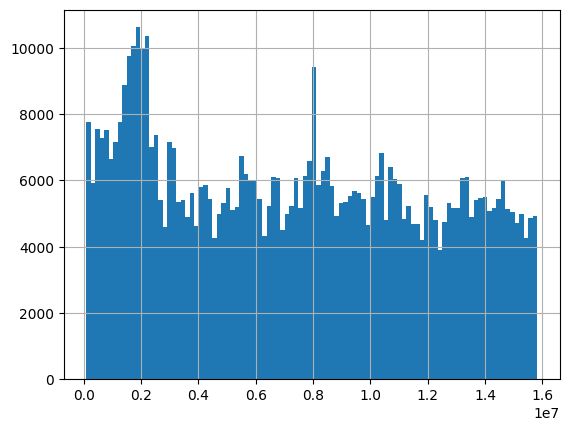

In [77]:
train_transaction["TransactionDT"].hist(bins=100)

In [78]:
# Merge transaction + identity first
train = train_transaction.merge(train_identity, on='TransactionID', how='left')

# Now split by time yourself
threshold = train['TransactionDT'].quantile(0.80)
X_train = train[train['TransactionDT'] < threshold].copy()
X_val   = train[train['TransactionDT'] >= threshold].copy()

In [79]:
print(train.shape)
print(X_train.shape)
print(X_val.shape)
print(X_train['isFraud'].mean())
print(X_val['isFraud'].mean())

(590540, 434)
(472432, 434)
(118108, 434)
0.03513521522674162
0.034409184813899145


In [80]:
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

In [81]:
features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6"
]

In [82]:
for col in ["ProductCD","card4","card6"]:
    train[col] = train[col].astype("category")

X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [83]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 271
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [84]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [85]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.1402794115739693


In [86]:
features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",

    "DeviceType",
    "id_30",
    "id_31",

    "P_emaildomain",
    "R_emaildomain",

    "addr1",
    "addr2",

    "M4",
    "M6"
]

for col in features:
    if train[col].dtype == "object":
        train[col] = train[col].astype("category")

In [87]:


X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [88]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [89]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [90]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.19949041390926203


In [91]:
features += [
    "V188",
    "V189",
    "V200",
    "V201",

    "V242",
    "V244",
    "V246",
    "V257",
    "V258"
]


In [92]:


X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [93]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 984
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [94]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [95]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.3827499096991183


In [96]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

           feature  importance
0   TransactionAmt        1203
9            addr1        1032
6            id_31         703
7    P_emaildomain         628
5            id_30         401
11              M4         343
8    R_emaildomain         268
12              M6         193
2            card4         144
14            V189         139
10           addr2         130
21            V258         125
1        ProductCD         114
3            card6          98
13            V188          89
15            V200          77
16            V201          74
17            V242          72
20            V257          51
18            V244          46


In [97]:
features += [
    "V147","V148","V149",
    "V154","V155","V156",
    "V157","V158"
]

In [98]:


X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [99]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1083
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [100]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [101]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.39117510575535547


In [102]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(40))

           feature  importance
0   TransactionAmt        1126
9            addr1         977
6            id_31         681
7    P_emaildomain         650
5            id_30         364
11              M4         324
8    R_emaildomain         253
12              M6         181
2            card4         134
14            V189         134
21            V258         116
1        ProductCD         104
10           addr2         104
3            card6          89
22            V147          73
15            V200          73
16            V201          67
27            V156          67
13            V188          65
17            V242          56
24            V149          54
20            V257          49
25            V154          43
23            V148          40
4       DeviceType          39
29            V158          38
18            V244          32
19            V246          32
28            V157          32
26            V155           3


In [103]:
features += [
    "D1","D2","D3","D4","D5",
    "D10","D11","D15"
]

In [104]:


X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [105]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3123
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [106]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [107]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {ap_score}")

Average Precision Score: 0.43086773099782427


In [108]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(40))

           feature  importance
0   TransactionAmt         619
9            addr1         538
6            id_31         533
7    P_emaildomain         432
31              D2         404
37             D15         383
33              D4         376
5            id_30         279
30              D1         263
35             D10         250
11              M4         242
8    R_emaildomain         212
32              D3         170
36             D11         159
34              D5         112
12              M6         106
1        ProductCD          95
14            V189          85
2            card4          85
10           addr2          77
3            card6          66
21            V258          65
27            V156          53
16            V201          49
22            V147          38
15            V200          38
17            V242          36
24            V149          32
25            V154          28
23            V148          26
13            V188          26
29      

In [109]:
train["MissingCount"] = train.isnull().sum(axis=1)

In [110]:
features += ["MissingCount"]

In [111]:
x_train = train[train["TransactionDT"] < threshold]
x_val   = train[train["TransactionDT"] >= threshold]

In [112]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    x_train[features],
    x_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014378 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3299
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [113]:
print("MissingCount" in X_train.columns)

print(set(features) - set(X_train.columns))

print(features[-10:])

False
{'MissingCount'}
['V158', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'MissingCount']


In [114]:
X_train.columns[X_train.columns.str.contains("Missing")]

Index([], dtype='object')

In [115]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [116]:
print("MissingCount" in X_train.columns)

True


In [117]:
features = list(dict.fromkeys(features))

In [118]:
features[-10:]

['V158', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'MissingCount']

In [119]:
print(set(features) - set(X_train.columns))

set()


In [120]:
print("MissingCount" in train.columns)

X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

features = list(dict.fromkeys(features))

print("MissingCount" in X_train.columns)
print(set(features) - set(X_train.columns))

True
True
set()


In [121]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014735 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3299
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [122]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [123]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {ap_score}")

Average Precision Score: 0.42656793876972554


In [124]:
features = [f for f in features if f != "MissingCount"]

In [125]:
train["EmailMatch"] = (
    train["P_emaildomain"].astype(str)
    ==
    train["R_emaildomain"].astype(str)
).astype(int)

In [126]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

features.append("EmailMatch")

In [127]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016479 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [128]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [129]:
from sklearn.metrics import average_precision_score

avg_precision = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {avg_precision}")

Average Precision Score: 0.4252274083676712


In [130]:
features = [f for f in features if f != "EmailMatch"]

In [131]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print("PR-AUC:", pr_auc)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3123
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.45352237849046084


In [132]:
scale_pos_weight = (
    len(X_train[X_train["isFraud"] == 0])
    /
    len(X_train[X_train["isFraud"] == 1])
)

print(scale_pos_weight)

27.46147358274595


In [133]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    scale_pos_weight=27.46147358274595,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print("PR-AUC:", pr_auc)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3123
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.43569867747122293


In [134]:
features += [
    "C1","C2","C3","C4","C5",
    "C6","C7","C8","C9","C10",
    "C11","C12","C13","C14"
]

In [135]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6366
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [136]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [137]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {ap_score}")

Average Precision Score: 0.5019102514933917


In [144]:
m_cols = ["M1","M2","M3","M5","M7","M8","M9"]
for col in m_cols:
    train[col] = train[col].map({"T": 1, "F": 0})

X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()
features += [
    "M1","M2","M3",
    "M5","M7","M8","M9"
]
features = list(dict.fromkeys(features))
print(len(features))

59


In [145]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)   

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018638 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6366
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [146]:
for col in ["M1","M2","M3","M5","M7","M8","M9"]:
    print(col)
    print(train[col].value_counts(dropna=False).head())
    print()

M1
M1
NaN    590540
Name: count, dtype: int64

M2
M2
NaN    590540
Name: count, dtype: int64

M3
M3
NaN    590540
Name: count, dtype: int64

M5
M5
NaN    590540
Name: count, dtype: int64

M7
M7
NaN    590540
Name: count, dtype: int64

M8
M8
NaN    590540
Name: count, dtype: int64

M9
M9
NaN    590540
Name: count, dtype: int64



In [147]:
m_cols = ["M1","M2","M3","M5","M7","M8","M9"]

for col in m_cols:
    train[col] = train[col].map({
        "T": 1,
        "F": 0
    })

In [148]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [149]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6366
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [150]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [151]:
from sklearn.metrics import average_precision_score

aps = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {aps}")

Average Precision Score: 0.5019102514933917


In [152]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(50))

           feature  importance
6            id_31         526
9            addr1         395
0   TransactionAmt         374
7    P_emaildomain         374
50             C13         279
5            id_30         266
37             D15         244
38              C1         244
31              D2         242
8    R_emaildomain         216
33              D4         209
30              D1         203
51             C14         182
43              C6         178
35             D10         176
46              C9         170
39              C2         162
32              D3         150
42              C5         130
36             D11         119
48             C11         118
11              M4         100
49             C12          80
3            card6          79
12              M6          73
2            card4          71
45              C8          64
1        ProductCD          64
34              D5          50
21            V258          45
47             C10          42
24      

In [153]:
features += [
    "V39","V40","V42",
    "V43","V44","V45"
]

In [154]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6475
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [155]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [156]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5314541913598061


In [157]:
features += [
    "V170",
    "V171"
]

In [158]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6544
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [159]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [160]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5261702127733807


In [161]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(50))

           feature  importance
9            addr1        2738
0   TransactionAmt        2736
6            id_31        1699
37             D15        1676
50             C13        1573
31              D2        1324
33              D4        1314
7    P_emaildomain        1292
35             D10        1268
30              D1        1050
38              C1         960
39              C2         958
5            id_30         887
36             D11         850
43              C6         804
51             C14         732
48             C11         699
32              D3         696
46              C9         670
8    R_emaildomain         544
42              C5         542
11              M4         539
34              D5         406
12              M6         384
45              C8         371
64             V45         356
49             C12         322
47             C10         313
2            card4         246
3            card6         218
65            V170         193
21      

In [162]:

features += [
    "V46","V47","V48",
    "V49","V50","V51","V52"
]

In [163]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6597
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [164]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [165]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.529073197237716


In [166]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

In [167]:
xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [168]:
from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

XGBoost PR-AUC: 0.5070500371918489


In [169]:
print(len(features))

74


In [170]:
X_train[features].dtypes[
    X_train[features].dtypes == "category"
]

ProductCD        category
card4            category
card6            category
DeviceType       category
id_30            category
id_31            category
P_emaildomain    category
R_emaildomain    category
M4               category
M6               category
dtype: object

In [171]:
X_train_xgb = X_train[features].copy()
X_val_xgb   = X_val[features].copy()

In [172]:
print("MissingCount" in train.columns)
print("MissingCount" in X_train.columns)
print("MissingCount" in X_val.columns)

True
True
True


In [173]:
X_train["MissingCount"] = X_train.isnull().sum(axis=1)
X_val["MissingCount"]   = X_val.isnull().sum(axis=1)

In [174]:
print("MissingCount" in X_train.columns)

True


In [175]:
missing_features = [
    f for f in features
    if f not in X_train.columns
]

print(missing_features)

[]


In [176]:
X_train[['M1','M2','M3','M5','M7','M8','M9']].dtypes

M1    float64
M2    float64
M3    float64
M5    float64
M7    float64
M8    float64
M9    float64
dtype: object

In [177]:
m_cols = ['M1','M2','M3','M5','M7','M8','M9']

for col in m_cols:
    train[col] = train[col].astype('category')

In [178]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [181]:
# Run this before the ensemble predict cell
cat_cols = ['ProductCD','card4','card6','DeviceType','id_30','id_31',
            'P_emaildomain','R_emaildomain','M4','M6','DeviceBrand']

for col in cat_cols:
    if col in X_train.columns and str(X_train[col].dtype) == 'category':
        # Force val to use exactly the same categories as train
        X_val[col] = pd.Categorical(
            X_val[col], 
            categories=X_train[col].cat.categories
        )

In [184]:
for col in features:
    if str(X_train[col].dtype) == 'category':
        train_cats = set(X_train[col].cat.categories)
        val_cats = set(X_val[col].cat.categories)
        if train_cats != val_cats:
            print(col)
            print("  train only:", train_cats - val_cats)
            print("  val only:",   val_cats - train_cats)

In [185]:
for col in features:
    if col in train.columns and str(train[col].dtype) == 'category':
        # Re-encode from scratch using the full train df's categories
        unified_cats = train[col].cat.categories
        X_train[col] = pd.Categorical(X_train[col], categories=unified_cats)
        X_val[col]   = pd.Categorical(X_val[col],   categories=unified_cats)

# Re-slice to make sure everything is fresh
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

# Re-apply the category fix on the fresh slices
for col in features:
    if col in X_train.columns and str(train[col].dtype) == 'category':
        unified_cats = train[col].cat.categories
        X_train[col] = pd.Categorical(X_train[col], categories=unified_cats)
        X_val[col]   = pd.Categorical(X_val[col],   categories=unified_cats)

In [187]:
# Step 1: Nuclear re-encode from train df (single source of truth)
for col in features:
    if col in train.columns and str(train[col].dtype) == 'category':
        unified_cats = train[col].cat.categories
        train[col] = pd.Categorical(train[col], categories=unified_cats)

# Step 2: Fresh slice
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

# Step 3: Retrain on the clean slice
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train[features], X_train["isFraud"])

# Step 4: Now predict
lgb_preds = model.predict_proba(X_val[features])[:,1]

from sklearn.metrics import average_precision_score
print("LGB PR-AUC:", average_precision_score(X_val["isFraud"], lgb_preds))

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6597
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
LGB PR-AUC: 0.5044611145773601


In [188]:
from sklearn.metrics import average_precision_score

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * lgb_preds +
    0.5 * xgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

Ensemble PR-AUC: 0.5100086470483784


In [189]:
for v in ["V147","V148","V149"]:
    print(v, train[v].isna().mean()*100)

train[
    ["V147","V148","V149"]
].corr()

V147 86.12371727571374
V148 86.12371727571374
V149 86.12371727571374


,V147,V148,V149
V147,1.000000,0.415549,0.487752
V148,0.415549,1.000000,0.950232
V149,0.487752,0.950232,1.000000


In [190]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020600 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6597
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, random_state=42)

In [191]:
lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

In [192]:
for col in [
    'ProductCD','card4','card6',
    'DeviceType','id_30','id_31',
    'P_emaildomain','R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9'
]:
    if str(X_train[col].dtype) == 'category':
        print(
            col,
            len(X_train[col].cat.categories),
            len(X_val[col].cat.categories)
        )

ProductCD 5 5
card4 4 4
card6 4 4
DeviceType 2 2
id_30 75 75
id_31 130 130
P_emaildomain 59 59
R_emaildomain 60 60
M1 0 0
M2 0 0
M3 0 0
M4 3 3
M5 0 0
M6 2 2
M7 0 0
M8 0 0
M9 0 0


In [193]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

Ensemble PR-AUC: 0.5261235579795522


In [194]:
imp = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

imp.head(80)

,feature,importance
9,addr1,1123
6,id_31,1055
0,TransactionAmt,1007
7,P_emaildomain,765
50,C13,688
...,...,...
55,M5,0
54,M3,0
53,M2,0
52,M1,0


In [195]:
new_vs = [
    'V46','V47','V48','V49',
    'V50','V51','V52'
]

for v in new_vs:
    if v not in features:
        features.append(v)

In [196]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6597
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [197]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [198]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)    

PR-AUC: 0.529073197237716


In [199]:
import pandas as pd
import numpy as np

# All candidate columns you haven't added yet
candidate_cols = [c for c in X_train.columns 
                  if c not in features 
                  and c not in ['TransactionID','isFraud','TransactionDT']]

# Correlation with fraud for every remaining column
correlations = []
for col in candidate_cols:
    try:
        corr = X_train[col].fillna(-999).corr(X_train['isFraud'])
        null_pct = X_train[col].isnull().mean()
        correlations.append({
            'col': col,
            'corr': abs(corr),
            'null_pct': round(null_pct * 100, 1)
        })
    except:
        pass

corr_df = pd.DataFrame(correlations).sort_values('corr', ascending=False)
print(corr_df[corr_df['corr'] > 0.03].to_string())

              col      corr  null_pct
7              D7  0.154200      93.7
10            D12  0.148324      88.8
12            D14  0.147176      89.5
329         id_10  0.139385      87.0
328         id_09  0.139378      87.0
9              D9  0.139355      87.0
322         id_03  0.135208      88.6
323         id_04  0.135175      88.6
196          V211  0.134060      75.3
6              D6  0.133658      87.6
11            D13  0.133273      89.6
336         id_20  0.132998      75.3
333         id_17  0.131455      75.3
331         id_13  0.131353      77.7
330         id_11  0.130140      75.1
324         id_05  0.129841      75.8
325         id_06  0.129422      75.8
253          V273  0.129001      76.7
195          V210  0.128328      75.3
193          V208  0.128118      75.3
169          V180  0.127816      75.3
174          V185  0.127806      75.3
185          V198  0.127800      75.3
173          V184  0.127794      75.3
184          V197  0.127789      75.3
182         

In [200]:
new_ds = [
    "D6","D7","D8","D9",
    "D12","D13","D14"
]

for col in new_ds:
    if col not in features:
        features.append(col)

In [201]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8152
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [202]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [203]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5313775550225961


In [204]:
for col in [
    "D6","D7","D8","D9",
    "D12","D13","D14"
]:
    if col in features:
        features.remove(col)

In [205]:
print([c for c in features if c.startswith("D")])

['DeviceType', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']


In [206]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6597
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


In [207]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.529073197237716


In [208]:
for col in [
    "id_01","id_02",
    "id_03","id_04",
    "id_05","id_06",
    "id_09","id_10",
    "id_11","id_13",
    "id_17","id_20"
]:
    if col not in features:
        features.append(col)

In [209]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7554
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5362350199767165


In [210]:
new_vs = [
    'V167','V168','V169',
    'V172','V173','V174',
    'V175','V176','V177'
]

for col in new_vs:
    if col not in features:
        features.append(col)

In [211]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7852
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5360066248556412


In [212]:
for col in [
    'V167','V168','V169',
    'V172','V173','V174',
    'V175','V176','V177'
]:
    if col in features:
        features.remove(col)

In [213]:
new_ds = [
    'D6','D7','D8',
    'D9','D12',
    'D13','D14'
]

for col in new_ds:
    if col not in features:
        features.append(col)

In [214]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026240 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9109
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5379730621651373


In [215]:
for col in ['D6','D7','D8','D9','D12','D13','D14']:
    if col in features:
        features.remove(col)

In [216]:
imp = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(imp.head(80).to_string())

ValueError: All arrays must be of the same length

In [217]:
print("features:", len(features))
print("importances:", len(model.feature_importances_))
print(model.n_features_)

features: 86
importances: 93
93


In [218]:
print(model.feature_name_)

['TransactionAmt', 'ProductCD', 'card4', 'card6', 'DeviceType', 'id_30', 'id_31', 'P_emaildomain', 'R_emaildomain', 'addr1', 'addr2', 'M4', 'M6', 'V188', 'V189', 'V200', 'V201', 'V242', 'V244', 'V246', 'V257', 'V258', 'V147', 'V148', 'V149', 'V154', 'V155', 'V156', 'V157', 'V158', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'M1', 'M2', 'M3', 'M5', 'M7', 'M8', 'M9', 'V39', 'V40', 'V42', 'V43', 'V44', 'V45', 'V170', 'V171', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_09', 'id_10', 'id_11', 'id_13', 'id_17', 'id_20', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14']


In [219]:
imp = pd.DataFrame({
    "feature": model.feature_name_,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(imp.head(100).to_string())

           feature  importance
9            addr1        2191
0   TransactionAmt        2099
6            id_31        1692
37             D15        1398
50             C13        1193
7    P_emaildomain        1096
31              D2        1033
35             D10         968
33              D4         961
30              D1         917
85           id_20         912
38              C1         902
88              D8         849
39              C2         774
5            id_30         734
43              C6         690
75           id_02         653
46              C9         637
36             D11         632
48             C11         632
51             C14         585
32              D3         558
79           id_06         429
8    R_emaildomain         428
42              C5         427
11              M4         425
83           id_13         399
74           id_01         387
78           id_05         374
12              M6         362
92             D14         348
64      

In [220]:
remaining_ids = [
    c for c in X_train.columns
    if c.startswith("id_")
    and c not in features
]

print(remaining_ids)

['id_07', 'id_08', 'id_12', 'id_14', 'id_15', 'id_16', 'id_18', 'id_19', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [221]:
remaining_d = [
    c for c in X_train.columns
    if c.startswith("D")
    and c not in features
]

print(remaining_d)

['D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'DeviceInfo']


In [222]:
print(len(features))
print("D14" in features)
print("D13" in features)
print("D12" in features)

86
False
False
False


In [223]:
print(train["DeviceInfo"].nunique())

1786


In [224]:
print(train["DeviceInfo"].value_counts().head(20))

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
SM-G950F Build/NRD90M            225
Name: count, dtype: int64


In [225]:
features = list(model.feature_name_)



In [226]:
train["DeviceBrand"] = (
    train["DeviceInfo"]
    .fillna("missing")
    .str.split()
    .str[0]
)

print(train["DeviceBrand"].value_counts().head(20))
print(train["DeviceBrand"].nunique())

DeviceBrand
missing        471874
Windows         47775
iOS             19782
MacOS           12573
Trident/7.0      7440
Moto             2659
SAMSUNG          2302
rv:11.0          1901
rv:57.0           962
HUAWEI            719
SM-J700M          654
SM-G610M          511
SM-G531H          410
SM-G955U          387
HTC               383
SM-G950U          364
rv:59.0           362
SM-G935F          353
SM-G532M          316
ALE-L23           312
Name: count, dtype: int64
1183


In [227]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

Ensemble PR-AUC: 0.5454599901385438


In [228]:
from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

XGBoost PR-AUC: 0.5402695880393978


In [229]:
from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

XGB=0.0  LGB=1.0  PR-AUC=0.537973
XGB=0.1  LGB=0.9  PR-AUC=0.540524
XGB=0.2  LGB=0.8  PR-AUC=0.542544
XGB=0.3  LGB=0.7  PR-AUC=0.544027
XGB=0.4  LGB=0.6  PR-AUC=0.544952
XGB=0.5  LGB=0.5  PR-AUC=0.545460
XGB=0.6  LGB=0.4  PR-AUC=0.545499
XGB=0.7  LGB=0.3  PR-AUC=0.545026
XGB=0.8  LGB=0.2  PR-AUC=0.544008
XGB=0.9  LGB=0.1  PR-AUC=0.542434
XGB=1.0  LGB=0.0  PR-AUC=0.540270


In [230]:
train["DeviceBrand"] = train["DeviceBrand"].astype("category")

In [231]:
features.append("DeviceBrand")

In [232]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [233]:
print(train["DeviceBrand"].nunique())

1183


In [234]:
print(train["DeviceBrand"].value_counts().head(50))

DeviceBrand
missing        471874
Windows         47775
iOS             19782
MacOS           12573
Trident/7.0      7440
Moto             2659
SAMSUNG          2302
rv:11.0          1901
rv:57.0           962
HUAWEI            719
SM-J700M          654
SM-G610M          511
SM-G531H          410
SM-G955U          387
HTC               383
SM-G950U          364
rv:59.0           362
SM-G935F          353
SM-G532M          316
ALE-L23           312
Blade             301
SM-G950F          290
SM-G930V          285
Lenovo            278
SM-N950U          270
rv:58.0           269
rv:52.0           256
Pixel             235
Ilium             232
Hisense           221
SM-G570M          219
SM-A300H          204
hi6210sft         190
SM-J730GM         184
rv:48.0           178
BLADE             178
CAM-L03           172
SM-J320M          171
LG-M700           169
M4                165
Redmi             161
SM-G955F          161
SM-J510MN         158
SM-A520F          156
LG-D693n          15

In [235]:
train["DeviceBrand2"] = "Other"

train.loc[
    train["DeviceInfo"].str.contains(
        "SM-|SAMSUNG",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Samsung"

train.loc[
    train["DeviceInfo"].str.contains(
        "Huawei|ALE-|BLA-|CLT-",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Huawei"

train.loc[
    train["DeviceInfo"].str.contains(
        "iOS|iPhone",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Apple"

train.loc[
    train["DeviceInfo"].str.contains(
        "Windows",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Windows"

train.loc[
    train["DeviceInfo"].str.contains(
        "MacOS",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "MacOS"

train["DeviceBrand2"] = train["DeviceBrand2"].astype("category")

In [236]:
fraud_by_brand = (
    train.groupby("DeviceBrand")["isFraud"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(
    fraud_by_brand[
        fraud_by_brand["count"] >= 100
    ].head(50)
)

             count      mean
DeviceBrand                 
hi6210sft      190  0.947368
SM-A300H       204  0.828431
SM-A510M       134  0.537313
F5121          122  0.393443
SM-J320M       171  0.333333
SM-J500M       131  0.328244
SM-G530H       108  0.259259
WAS-LX3        108  0.259259
XT1635-02      110  0.236364
SM-A720F       137  0.226277
Hisense        221  0.217195
BLADE          178  0.213483
MotoG3         136  0.213235
SM-G900M       108  0.203704
SM-J701M       154  0.194805
rv:58.0        269  0.182156
SM-G955F       161  0.180124
Blade          301  0.176080
LG-M700        169  0.171598
Lenovo         278  0.154676
SM-J730GM      184  0.146739
LG-K580        117  0.145299
Moto          2659  0.141783
M4             165  0.139394
TRT-L53        122  0.139344
SM-G950F       290  0.131034
CAM-L03        172  0.127907
rv:59.0        362  0.121547
SM-G955U       387  0.118863
SM-J700M       654  0.111621
LG-X230        111  0.108108
rv:57.0        962  0.107069
Redmi         

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_1216/3075626571.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby("DeviceBrand")["isFraud"]


In [237]:
print(train["DeviceInfo"].isna().mean())
print(train["DeviceBrand"].isna().mean())

0.7990551021099332
0.0


In [238]:
features.append("DeviceBrand")

X_train["DeviceBrand"] = X_train["DeviceBrand"].astype("category")
X_val["DeviceBrand"] = X_val["DeviceBrand"].astype("category")

In [ ]:
# Seeing what's wrong
for col in features:
    print(col, X_train[col].dtype)

TransactionAmt float64
ProductCD category
card4 category
card6 category
DeviceType category
id_30 category
id_31 category
P_emaildomain category
R_emaildomain category
addr1 float64
addr2 float64
M4 category
M6 category
V188 float64
V189 float64
V200 float64
V201 float64
V242 float64
V244 float64
V246 float64
V257 float64
V258 float64
V147 float64
V148 float64
V149 float64
V154 float64
V155 float64
V156 float64
V157 float64
V158 float64
D1 float64
D2 float64
D3 float64
D4 float64
D5 float64
D10 float64
D11 float64
D15 float64
C1 float64
C2 float64
C3 float64
C4 float64
C5 float64
C6 float64
C7 float64
C8 float64
C9 float64
C10 float64
C11 float64
C12 float64
C13 float64
C14 float64
M1 category
M2 category
M3 category
M5 category
M7 category
M8 category
M9 category
V39 float64
V40 float64
V42 float64
V43 float64
V44 float64
V45 float64
V170 float64
V171 float64
V46 float64
V47 float64
V48 float64
V49 float64
V50 float64
V51 float64
V52 float64
id_01 float64
id_02 float64
id_03 float64
i

In [246]:
from collections import Counter

cnt = Counter(features)

dups = [k for k, v in cnt.items() if v > 1]
print("Duplicate feature names:", dups)
print("Number of duplicates:", len(dups))

Duplicate feature names: ['DeviceBrand']
Number of duplicates: 1


In [247]:
print(X_train[features].columns.duplicated().sum())

1


In [248]:
print(type(X_train))
print(type(X_train[features]))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [245]:
print(X_train["ProductCD"].dtype)
print(X_train["card4"].dtype)
print(X_train["DeviceBrand"].dtype)

category
category
category


In [249]:
features = list(dict.fromkeys(features))
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9364
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.536212704040592


In [250]:
from collections import Counter

duplicates = [x for x, c in Counter(features).items() if c > 1]
print(duplicates)

[]


In [251]:
print(len(features))
print(len(set(features)))

94
94


In [252]:
features.count("DeviceBrand")

1

In [253]:
features = list(dict.fromkeys(features))

In [254]:
print(features.count("DeviceBrand"))
print(len(features))
print(len(set(features)))

1
94
94


In [255]:
X_train["DeviceBrand"] = X_train["DeviceBrand"].astype("category")
X_val["DeviceBrand"] = X_val["DeviceBrand"].astype("category")

In [256]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9364
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.536212704040592


In [257]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5464709804213252
XGBoost PR-AUC: 0.5408359225197577
XGB=0.0  LGB=1.0  PR-AUC=0.536213
XGB=0.1  LGB=0.9  PR-AUC=0.539597
XGB=0.2  LGB=0.8  PR-AUC=0.542228
XGB=0.3  LGB=0.7  PR-AUC=0.544234
XGB=0.4  LGB=0.6  PR-AUC=0.545670
XGB=0.5  LGB=0.5  PR-AUC=0.546471
XGB=0.6  LGB=0.4  PR-AUC=0.546737
XGB=0.7  LGB=0.3  PR-AUC=0.546410
XGB=0.8  LGB=0.2  PR-AUC=0.545418
XGB=0.9  LGB=0.1  PR-AUC=0.543745
XGB=1.0  LGB=0.0  PR-AUC=0.540836


In [258]:
X_train["uid"] = (
    X_train["card1"].astype(str) + "_" +
    X_train["addr1"].astype(str)
)

X_val["uid"] = (
    X_val["card1"].astype(str) + "_" +
    X_val["addr1"].astype(str)
)

In [259]:
uid_count = X_train.groupby("uid").size()

X_train["uid_count"] = X_train["uid"].map(uid_count)

X_val["uid_count"] = (
    X_val["uid"]
    .map(uid_count)
    .fillna(0)
)

In [260]:
features.append("uid_count")

In [261]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028749 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9601
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 88
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5499866163447826


In [262]:
uid_amt_mean = (
    X_train.groupby("uid")
    ["TransactionAmt"]
    .mean()
)

X_train["uid_amt_mean"] = (
    X_train["uid"]
    .map(uid_amt_mean)
)

X_val["uid_amt_mean"] = (
    X_val["uid"]
    .map(uid_amt_mean)
    .fillna(
        X_train["TransactionAmt"].mean()
    )
)

In [263]:
features.append("uid_amt_mean")

In [264]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9856
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 89
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5563937942612822


In [265]:
X_train["uid_amt_ratio"] = (
    X_train["TransactionAmt"] /
    X_train["uid_amt_mean"]
)

X_val["uid_amt_ratio"] = (
    X_val["TransactionAmt"] /
    X_val["uid_amt_mean"]
)

In [266]:
features.append("uid_amt_ratio")

In [267]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029017 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10111
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5559161040043373


In [268]:
features.remove("uid_amt_ratio")

In [269]:
uid_amt_std = (
    X_train.groupby("uid")["TransactionAmt"]
    .std()
)

X_train["uid_amt_std"] = (
    X_train["uid"]
    .map(uid_amt_std)
    .fillna(0)
)

X_val["uid_amt_std"] = (
    X_val["uid"]
    .map(uid_amt_std)
    .fillna(0)
)

features.append("uid_amt_std")

In [270]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10111
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5580633632295555


In [271]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.572614434277614
XGBoost PR-AUC: 0.570198773237089
XGB=0.0  LGB=1.0  PR-AUC=0.558063
XGB=0.1  LGB=0.9  PR-AUC=0.562455
XGB=0.2  LGB=0.8  PR-AUC=0.566009
XGB=0.3  LGB=0.7  PR-AUC=0.568856
XGB=0.4  LGB=0.6  PR-AUC=0.571088
XGB=0.5  LGB=0.5  PR-AUC=0.572614
XGB=0.6  LGB=0.4  PR-AUC=0.573542
XGB=0.7  LGB=0.3  PR-AUC=0.573845
XGB=0.8  LGB=0.2  PR-AUC=0.573503
XGB=0.9  LGB=0.1  PR-AUC=0.572451
XGB=1.0  LGB=0.0  PR-AUC=0.570199


In [272]:
uid_C1_mean = (
    X_train.groupby("uid")["C1"]
    .mean()
)

X_train["uid_C1_mean"] = (
    X_train["uid"]
    .map(uid_C1_mean)
)

X_val["uid_C1_mean"] = (
    X_val["uid"]
    .map(uid_C1_mean)
    .fillna(
        X_train["C1"].mean()
    )
)

features.append("uid_C1_mean")

In [273]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10366
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 91
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5660371146267832


In [274]:
for col in ["C2", "C13", "C14"]:
    
    mapping = X_train.groupby("uid")[col].mean()

    X_train[f"uid_{col}_mean"] = X_train["uid"].map(mapping)

    X_val[f"uid_{col}_mean"] = (
        X_val["uid"]
        .map(mapping)
        .fillna(X_train[col].mean())
    )

    features.append(f"uid_{col}_mean")

In [275]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11131
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5738086359229637


In [276]:
for col in ["C5", "C6", "C11", "C12"]:
    
    mapping = X_train.groupby("uid")[col].mean()

    X_train[f"uid_{col}_mean"] = X_train["uid"].map(mapping)

    X_val[f"uid_{col}_mean"] = (
        X_val["uid"]
        .map(mapping)
        .fillna(X_train[col].mean())
    )

    features.append(f"uid_{col}_mean")

In [277]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12151
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5690932212586888


In [278]:
bad_features = [
    "uid_C5_mean",
    "uid_C6_mean",
    "uid_C11_mean",
    "uid_C12_mean"
]

# Remove from train/val
X_train.drop(columns=bad_features, inplace=True)
X_val.drop(columns=bad_features, inplace=True)

# Remove from features list
features = [f for f in features if f not in bad_features]

print(len(features))

101


In [279]:
uid_stats = X_train.groupby("uid")["TransactionAmt"].agg(
    ["mean", "std", "count"]
)

for stat in ["mean", "std", "count"]:
    mapping = uid_stats[stat]

    X_train[f"uid_amt_{stat}"] = X_train["uid"].map(mapping)

    X_val[f"uid_amt_{stat}"] = (
        X_val["uid"]
        .map(mapping)
        .fillna(mapping.mean())
    )

    features.append(f"uid_amt_{stat}")

In [281]:
features = list(dict.fromkeys(features))
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11368
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5727749541268198


In [ ]:
from collections import Counter

duplicates = [f for f, c in Counter(features).items() if c > 1]
print(duplicates)

['uid_amt_mean', 'uid_amt_std', 'uid_amt_count']


In [ ]:
features = list(dict.fromkeys(features))

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11389
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5747269995924178


In [282]:
features = [f for f in features if f not in [
    "uid_amt_mean",
    "uid_amt_std",
    "uid_amt_count"
]]

In [283]:
print("uid_amt_mean" in features)
print("uid_amt_std" in features)
print("uid_amt_count" in features)
print(len(features))

False
False
False
99


In [284]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10621
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5676585847399296


In [285]:
features.append("uid_amt_mean")

In [286]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029031 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10876
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5701224526648541


In [287]:
features.append("uid_amt_count")

In [288]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11113
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5701224526648541


In [289]:
print([f for f in features if "uid_" in f])
print(len(features))

['uid_count', 'uid_C1_mean', 'uid_C2_mean', 'uid_C13_mean', 'uid_C14_mean', 'uid_amt_mean', 'uid_amt_count']
101


In [290]:
for col in ["uid_amt_mean", "uid_amt_count"]:
    print(col, col in features)

uid_amt_mean True
uid_amt_count True


In [291]:
features = [
    f for f in features
    if f not in ["uid_amt_mean", "uid_amt_count"]
]

In [292]:
print(len(features))

for col in [
    "DeviceBrand",
    "uid_count",
    "uid_C1_mean",
    "uid_C2_mean",
    "uid_C13_mean",
    "uid_C14_mean",
    "uid_amt_mean",
    "uid_amt_count"
]:
    print(col, col in features)

99
DeviceBrand True
uid_count True
uid_C1_mean True
uid_C2_mean True
uid_C13_mean True
uid_C14_mean True
uid_amt_mean False
uid_amt_count False


In [293]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10621
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5676585847399296


In [294]:
base_features = [
    'TransactionAmt', 'ProductCD', 'card4', 'card6',
    'DeviceType', 'id_30', 'id_31',
    'P_emaildomain', 'R_emaildomain',
    'addr1', 'addr2',
    'M4', 'M6',
    'V188', 'V189', 'V200', 'V201',
    'V242', 'V244', 'V246',
    'V257', 'V258',
    'V147', 'V148', 'V149',
    'V154', 'V155', 'V156', 'V157', 'V158',
    'D1','D2','D3','D4','D5','D10','D11','D15',
    'C1','C2','C3','C4','C5','C6','C7',
    'C8','C9','C10','C11','C12','C13','C14',
    'M1','M2','M3','M5','M7','M8','M9',
    'V39','V40','V42','V43','V44','V45',
    'V170','V171',
    'V46','V47','V48','V49','V50','V51','V52',
    'id_01','id_02','id_03','id_04','id_05',
    'id_06','id_09','id_10','id_11',
    'id_13','id_17','id_20',
    'D6','D7','D8','D9','D12','D13','D14'
]

In [295]:
features = base_features.copy()

features += [
    "DeviceBrand",
    "uid_count",
    "uid_C1_mean",
    "uid_C2_mean",
    "uid_C13_mean",
    "uid_C14_mean"
]

In [296]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033566 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10621
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5676585847399296


In [297]:
if "uid_amt_mean" not in features:
    features.append("uid_amt_mean")

if "uid_amt_std" not in features:
    features.append("uid_amt_std")

print(len(features))

101


In [298]:
print("uid_amt_mean" in X_train.columns)
print("uid_amt_std" in X_train.columns)

True
True


In [299]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11131
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5727749541268198


In [300]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5863471610599912
XGBoost PR-AUC: 0.5822472108281259
XGB=0.0  LGB=1.0  PR-AUC=0.572775
XGB=0.1  LGB=0.9  PR-AUC=0.576920
XGB=0.2  LGB=0.8  PR-AUC=0.580305
XGB=0.3  LGB=0.7  PR-AUC=0.582932
XGB=0.4  LGB=0.6  PR-AUC=0.584959
XGB=0.5  LGB=0.5  PR-AUC=0.586347
XGB=0.6  LGB=0.4  PR-AUC=0.587033
XGB=0.7  LGB=0.3  PR-AUC=0.587033
XGB=0.8  LGB=0.2  PR-AUC=0.586392
XGB=0.9  LGB=0.1  PR-AUC=0.585034
XGB=1.0  LGB=0.0  PR-AUC=0.582247


In [301]:
X_train["uid_amt_zscore"] = (
    X_train["TransactionAmt"] - X_train["uid_amt_mean"]
) / (X_train["uid_amt_std"] + 1)

X_val["uid_amt_zscore"] = (
    X_val["TransactionAmt"] - X_val["uid_amt_mean"]
) / (X_val["uid_amt_std"] + 1)

In [302]:
if "uid_amt_zscore" not in features:
    features.append("uid_amt_zscore")

In [303]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11386
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5722608797380333


In [304]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5849663252283874
XGBoost PR-AUC: 0.5810109561744009
XGB=0.0  LGB=1.0  PR-AUC=0.572261
XGB=0.1  LGB=0.9  PR-AUC=0.576229
XGB=0.2  LGB=0.8  PR-AUC=0.579443
XGB=0.3  LGB=0.7  PR-AUC=0.581905
XGB=0.4  LGB=0.6  PR-AUC=0.583703
XGB=0.5  LGB=0.5  PR-AUC=0.584966
XGB=0.6  LGB=0.4  PR-AUC=0.585576
XGB=0.7  LGB=0.3  PR-AUC=0.585462
XGB=0.8  LGB=0.2  PR-AUC=0.584791
XGB=0.9  LGB=0.1  PR-AUC=0.583445
XGB=1.0  LGB=0.0  PR-AUC=0.581011


In [305]:
features = [f for f in features if f != "uid_amt_zscore"]

In [306]:
uid_amt_max_map = X_train.groupby("uid")["TransactionAmt"].max()

X_train["uid_amt_max"] = X_train["uid"].map(uid_amt_max_map)
X_val["uid_amt_max"] = X_val["uid"].map(uid_amt_max_map)

In [307]:
uid_amt_min_map = X_train.groupby("uid")["TransactionAmt"].min()

X_train["uid_amt_min"] = X_train["uid"].map(uid_amt_min_map)
X_val["uid_amt_min"] = X_val["uid"].map(uid_amt_min_map)

In [308]:
if "uid_amt_max" not in features:
    features.append("uid_amt_max")

In [309]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11384
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5730240464814828


In [310]:
features = [f for f in features if f != "uid_amt_max"]

In [311]:
if "uid_amt_min" not in features:
    features.append("uid_amt_min")

In [312]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11386
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5729464812519475


In [313]:
features = [f for f in features if f != "uid_amt_min"]

In [314]:
if "uid_amt_max" not in features:
    features.append("uid_amt_max")

In [315]:
X_train["amt_to_uid_max"] = (
    X_train["TransactionAmt"]
    / (X_train["uid_amt_max"] + 1)
)

X_val["amt_to_uid_max"] = (
    X_val["TransactionAmt"]
    / (X_val["uid_amt_max"] + 1)
)

In [316]:
if "amt_to_uid_max" not in features:
    features.append("amt_to_uid_max")

In [317]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11639
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5705314893243704


In [318]:
features = [f for f in features if f != "amt_to_uid_max"]

In [319]:
print("TransactionDT" in train.columns)

True


In [320]:
for df in [X_train, X_val]:

    df["D1n"] = (
        np.floor(df["TransactionDT"]/(24*60*60))
        - df["D1"]
    )

In [321]:
features.append("D1n")

In [322]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037510 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11608
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5805192235079308


In [323]:
for df in [X_train, X_val]:

    df["uid2"] = (
        df["card1"].astype(str) + "_" +
        df["card2"].astype(str) + "_" +
        df["card3"].astype(str) + "_" +
        df["card5"].astype(str)
    )

In [324]:
uid2_amt_mean = X_train.groupby(
    "uid2"
)["TransactionAmt"].mean()

X_train["uid2_amt_mean"] = X_train["uid2"].map(uid2_amt_mean)
X_val["uid2_amt_mean"] = X_val["uid2"].map(uid2_amt_mean)

In [325]:
features.append("uid2_amt_mean")

In [326]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11863
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5751076537978705


In [327]:
uid2_amt_std_map = X_train.groupby(
    "uid2"
)["TransactionAmt"].std()

X_train["uid2_amt_std"] = X_train["uid2"].map(
    uid2_amt_std_map
)

X_val["uid2_amt_std"] = X_val["uid2"].map(
    uid2_amt_std_map
)

In [328]:
if "uid2_amt_std" not in features:
    features.append("uid2_amt_std")

In [329]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12118
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5817733943345452


In [330]:
for df in [X_train, X_val]:

    df["uid3"] = (
        df["card1"].astype(str) + "_" +
        df["card2"].astype(str) + "_" +
        df["card3"].astype(str) + "_" +
        df["card5"].astype(str) + "_" +
        df["addr1"].astype(str) + "_" +
        df["addr2"].astype(str)
    )

In [331]:
uid3_amt_mean_map = X_train.groupby(
    "uid3"
)["TransactionAmt"].mean()

X_train["uid3_amt_mean"] = X_train["uid3"].map(
    uid3_amt_mean_map
)

X_val["uid3_amt_mean"] = X_val["uid3"].map(
    uid3_amt_mean_map
)

In [332]:
if "uid3_amt_mean" not in features:
    features.append("uid3_amt_mean")

In [333]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5847344964781465


In [334]:
features = [f for f in features if f != "uid3_amt_mean"]

In [335]:
uid2_count_map = X_train.groupby("uid2").size()

X_train["uid2_count"] = X_train["uid2"].map(uid2_count_map)
X_val["uid2_count"] = X_val["uid2"].map(uid2_count_map)

In [336]:
if "uid2_count" not in features:
    features.append("uid2_count")

In [337]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035508 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12352
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5849703387429419


In [338]:
features = [f for f in features if f != "uid2_count"]

In [339]:
uid2_C13_mean_map = X_train.groupby(
    "uid2"
)["C13"].mean()

X_train["uid2_C13_mean"] = X_train["uid2"].map(
    uid2_C13_mean_map
)

X_val["uid2_C13_mean"] = X_val["uid2"].map(
    uid2_C13_mean_map
)

In [340]:
if "uid2_C13_mean" not in features:
    features.append("uid2_C13_mean")

In [341]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032937 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5832266046947773


In [342]:
features = [f for f in features if f != "uid2_C13_mean"]

In [343]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12118
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5817733943345452


In [344]:
for df in [X_train, X_val]:

    df["uid_d1"] = (
        df["card1"].astype(str)
        + "_"
        + (
            np.floor(df["TransactionDT"]/(24*60*60) - df["D1"])
        ).astype(str)
    )

In [345]:
uid_d1_amt_mean_map = X_train.groupby(
    "uid_d1"
)["TransactionAmt"].mean()

X_train["uid_d1_amt_mean"] = X_train["uid_d1"].map(
    uid_d1_amt_mean_map
)

X_val["uid_d1_amt_mean"] = X_val["uid_d1"].map(
    uid_d1_amt_mean_map
)

In [346]:
features.append("uid_d1_amt_mean")

In [347]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5712097701977694


In [348]:
features = [f for f in features if f != "uid_d1_amt_mean"]

In [349]:
print("uid_d1_amt_mean" in features)

False


In [352]:
print("Features used by model:", len(model.feature_name_))
print("Current features:", len(features))

missing = set(model.feature_name_) - set(features)
extra = set(features) - set(model.feature_name_)

print("Missing:", missing)
print("Extra:", extra)

Features used by model: 106
Current features: 105
Missing: {'uid_d1_amt_mean'}
Extra: set()


In [353]:
print("uid_d1_amt_mean" in X_train.columns)
print("uid_d1_amt_mean" in X_val.columns)


True
True


In [354]:
features.append("uid_d1_amt_mean")

In [355]:
features = list(dict.fromkeys(features))
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5921641989558362
XGBoost PR-AUC: 0.5900215993884527
XGB=0.0  LGB=1.0  PR-AUC=0.571210
XGB=0.1  LGB=0.9  PR-AUC=0.577519
XGB=0.2  LGB=0.8  PR-AUC=0.582650
XGB=0.3  LGB=0.7  PR-AUC=0.586694
XGB=0.4  LGB=0.6  PR-AUC=0.589861
XGB=0.5  LGB=0.5  PR-AUC=0.592164
XGB=0.6  LGB=0.4  PR-AUC=0.593553
XGB=0.7  LGB=0.3  PR-AUC=0.594092
XGB=0.8  LGB=0.2  PR-AUC=0.593815
XGB=0.9  LGB=0.1  PR-AUC=0.592596
XGB=1.0  LGB=0.0  PR-AUC=0.590022


In [356]:
print("Features used by model:", len(model.feature_name_))
print("Current features:", len(features))

missing = set(model.feature_name_) - set(features)
extra = set(features) - set(model.feature_name_)

print("Missing from current features:")
print(missing)

print("\nExtra in current features:")
print(extra)

Features used by model: 106
Current features: 106
Missing from current features:
set()

Extra in current features:
set()


In [357]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5712097701977694


In [358]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5921641989558362
XGBoost PR-AUC: 0.5900215993884527
XGB=0.0  LGB=1.0  PR-AUC=0.571210
XGB=0.1  LGB=0.9  PR-AUC=0.577519
XGB=0.2  LGB=0.8  PR-AUC=0.582650
XGB=0.3  LGB=0.7  PR-AUC=0.586694
XGB=0.4  LGB=0.6  PR-AUC=0.589861
XGB=0.5  LGB=0.5  PR-AUC=0.592164
XGB=0.6  LGB=0.4  PR-AUC=0.593553
XGB=0.7  LGB=0.3  PR-AUC=0.594092
XGB=0.8  LGB=0.2  PR-AUC=0.593815
XGB=0.9  LGB=0.1  PR-AUC=0.592596
XGB=1.0  LGB=0.0  PR-AUC=0.590022


In [359]:
import joblib

joblib.dump(model, "lgb_best.pkl")
joblib.dump(xgb_model, "xgb_best.pkl")
joblib.dump(features, "features_best.pkl")

['features_best.pkl']

In [360]:
import os

print(os.path.exists("lgb_best.pkl"))
print(os.path.exists("xgb_best.pkl"))
print(os.path.exists("features_best.pkl"))

True
True
True


In [361]:
for df in [X_train, X_val]:
    df["uid4"] = (
        df["card1"].astype(str) + "_" +
        df["card2"].astype(str) + "_" +
        df["card3"].astype(str) + "_" +
        df["card5"].astype(str) + "_" +
        df["addr1"].astype(str) + "_" +
        df["addr2"].astype(str) + "_" +
        df["P_emaildomain"].astype(str)
    )

In [362]:
uid4_amt_mean_map = X_train.groupby("uid4")["TransactionAmt"].mean()

X_train["uid4_amt_mean"] = X_train["uid4"].map(uid4_amt_mean_map)
X_val["uid4_amt_mean"] = X_val["uid4"].map(uid4_amt_mean_map)

In [363]:
if "uid4_amt_mean" not in features:
    features.append("uid4_amt_mean")

In [364]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12628
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5722956901979258


In [365]:
features = [f for f in features if f != "uid4_amt_mean"]

In [366]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030112 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5712097701977694


In [367]:
card1_amt_mean_map = X_train.groupby(
    "card1"
)["TransactionAmt"].mean()

X_train["card1_amt_mean"] = X_train["card1"].map(card1_amt_mean_map)
X_val["card1_amt_mean"] = X_val["card1"].map(card1_amt_mean_map)

if "card1_amt_mean" not in features:
    features.append("card1_amt_mean")

In [368]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12628
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5677432029780134


In [369]:
features = [f for f in features if f != "card1_amt_mean"]

In [370]:
print("uid_d1_amt_mean" in features)
print("card1_amt_mean" in features)

True
False


In [371]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5712097701977694


In [372]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=12,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.4,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.6099783892159475
XGBoost PR-AUC: 0.6099155264253738
XGB=0.0  LGB=1.0  PR-AUC=0.571210
XGB=0.1  LGB=0.9  PR-AUC=0.582276
XGB=0.2  LGB=0.8  PR-AUC=0.591489
XGB=0.3  LGB=0.7  PR-AUC=0.599145
XGB=0.4  LGB=0.6  PR-AUC=0.605313
XGB=0.5  LGB=0.5  PR-AUC=0.609978
XGB=0.6  LGB=0.4  PR-AUC=0.613245
XGB=0.7  LGB=0.3  PR-AUC=0.615062
XGB=0.8  LGB=0.2  PR-AUC=0.615285
XGB=0.9  LGB=0.1  PR-AUC=0.613830
XGB=1.0  LGB=0.0  PR-AUC=0.609916


In [373]:
model = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=256,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)
from lightgbm import early_stopping

model.fit(
    X_train[features],
    X_train["isFraud"],
    eval_set=[(X_val[features], X_val["isFraud"])],
    eval_metric="average_precision",
    callbacks=[early_stopping(100)]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025687 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[893]	valid_0's average_precision: 0.612701	valid_0's binary_logloss: 0.0802483
PR-AUC: 0.612700927916644


In [2]:
features = list(dict.fromkeys(features))



NameError: name 'features' is not defined

In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=12,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.4,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"],
    eval_set=[(X_val[features], X_val["isFraud"])],
    verbose=100
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

NameError: name 'features' is not defined

In [ ]:
print("LGB best iteration:", model.best_iteration_)
print("XGB best iteration:", getattr(xgb_model, "best_iteration", None))

LGB best iteration: 893
XGB best iteration: None


In [ ]:
import joblib

joblib.dump(model, "lgb_634.pkl")
joblib.dump(xgb_model, "xgb_634.pkl")
joblib.dump(features, "features_634.pkl")

['features_634.pkl']

In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

best_score = -1
best_w = None

for w in np.arange(0.40, 0.71, 0.01):

    preds = (
        w * xgb_preds +
        (1 - w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    if score > best_score:
        best_score = score
        best_w = w

    print(f"{w:.2f} -> {score:.6f}")

print(best_w, best_score)

0.40 -> 0.605313
0.41 -> 0.605843
0.42 -> 0.606370
0.43 -> 0.606860
0.44 -> 0.607357
0.45 -> 0.607822
0.46 -> 0.608299
0.47 -> 0.608728
0.48 -> 0.609156
0.49 -> 0.609575
0.50 -> 0.609978
0.51 -> 0.610378
0.52 -> 0.610733
0.53 -> 0.611104
0.54 -> 0.611481
0.55 -> 0.611807
0.56 -> 0.612108
0.57 -> 0.612417
0.58 -> 0.612702
0.59 -> 0.612987
0.60 -> 0.613245
0.61 -> 0.613518
0.62 -> 0.613748
0.63 -> 0.613971
0.64 -> 0.614167
0.65 -> 0.614341
0.66 -> 0.614507
0.67 -> 0.614668
0.68 -> 0.614822
0.69 -> 0.614937
0.70 -> 0.615062
0.7000000000000003 0.6150619389895757


In [ ]:
cat_features = []

for col in features:
    if str(X_train[col].dtype) == "category":
        cat_features.append(col)

print(cat_features)

['ProductCD', 'card4', 'card6', 'DeviceType', 'id_30', 'id_31', 'P_emaildomain', 'R_emaildomain', 'M4', 'M6', 'M1', 'M2', 'M3', 'M5', 'M7', 'M8', 'M9', 'DeviceBrand']
